In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# Load SPY
df = yf.download("SPY", start="2010-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

# SMA 50/200 strategy returns
sma50  = price.rolling(50).mean()
sma200 = price.rolling(200).mean()
sma_position = (sma50 > sma200).astype(int).shift(1).fillna(0)
sma_position = sma_position.reindex(log_returns.index).fillna(0)
sma_trades   = sma_position.diff().abs().fillna(0)
sma_returns  = sma_position * log_returns - sma_trades * 0.0006

print(f"SMA strategy returns ready")
print(f"  Mean daily return : {sma_returns.mean():.6f}")
print(f"  Daily variance    : {sma_returns.var():.8f}")
print(f"  Ann. Sharpe       : {(sma_returns.mean()*252-0.02)/(sma_returns.std()*np.sqrt(252)):.2f}")

[*********************100%***********************]  1 of 1 completed

SMA strategy returns ready
  Mean daily return : 0.000322
  Daily variance    : 0.00007567
  Ann. Sharpe       : 0.44


In [3]:
def kelly_fraction(returns):
    """
    Kelly fraction for continuous return strategy.
    Kelly = mean(returns) / variance(returns)
    """
    mu     = returns.mean()
    sigma2 = returns.var()
    kelly  = mu / sigma2
    return kelly

# Calculate Kelly for SMA strategy
kelly_sma = kelly_fraction(sma_returns)

print(f"Kelly fraction (daily basis): {kelly_sma:.2f}")
print(f"\nInterpretation:")
print(f"  Full Kelly says bet {kelly_sma:.1f}x your capital per trade")
print(f"  (i.e. {kelly_sma:.1f}x leverage)")
print(f"\n  Half Kelly  : {kelly_sma/2:.2f}x")
print(f"  Quarter Kelly: {kelly_sma/4:.2f}x")

Kelly fraction (daily basis): 4.25

Interpretation:
  Full Kelly says bet 4.2x your capital per trade
  (i.e. 4.2x leverage)

  Half Kelly  : 2.12x
  Quarter Kelly: 1.06x


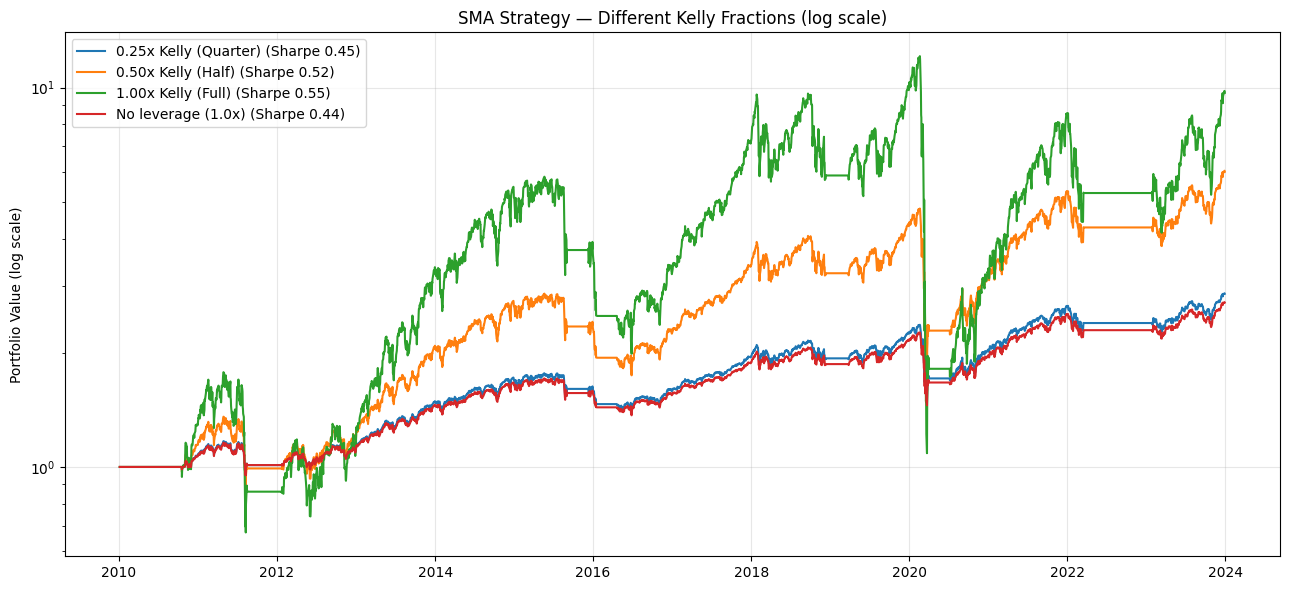


  Fraction                   Leverage   Ann Ret   Sharpe    Max DD
  0.25x Kelly (Quarter)         1.06x      8.6%     0.45    -37.6%
  0.50x Kelly (Half)            2.12x     17.2%     0.52    -64.0%
  1.00x Kelly (Full)            4.25x     34.4%     0.55    -91.0%
  No leverage (1.0x)            1.00x      8.1%     0.44    -35.7%


In [4]:
# Simulate different Kelly fractions
fractions = {
    "0.25x Kelly (Quarter)": kelly_sma * 0.25,
    "0.50x Kelly (Half)"   : kelly_sma * 0.50,
    "1.00x Kelly (Full)"   : kelly_sma * 1.00,
    "No leverage (1.0x)"   : 1.0,
}

results = []
fig, ax = plt.subplots(figsize=(13, 6))

for name, frac in fractions.items():
    scaled_ret = sma_returns * frac
    equity = (1 + scaled_ret).cumprod()

    ar = scaled_ret.mean() * 252
    av = scaled_ret.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    dd = ((equity - equity.cummax()) / equity.cummax()).min()

    results.append({"name": name, "fraction": frac,
                    "ann_ret": ar, "sharpe": sh, "max_dd": dd})

    ax.plot(equity, lw=1.5, label=f"{name} (Sharpe {sh:.2f})")

ax.set_yscale('log')
ax.set_title('SMA Strategy — Different Kelly Fractions (log scale)')
ax.set_ylabel('Portfolio Value (log scale)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'='*65}")
print(f"  {'Fraction':<25} {'Leverage':>9} {'Ann Ret':>9} {'Sharpe':>8} {'Max DD':>9}")
print(f"{'='*65}")
for r in results:
    print(f"  {r['name']:<25} {r['fraction']:>8.2f}x {r['ann_ret']:>9.1%} {r['sharpe']:>8.2f} {r['max_dd']:>9.1%}")
print(f"{'='*65}")

In [5]:
def position_sizer(capital, kelly_fraction, price,
                   kelly_multiplier=0.5):
    """
    Calculate position size in dollars and shares.

    capital         : total account capital
    kelly_fraction  : Kelly fraction (e.g. 4.25)
    price           : current asset price
    kelly_multiplier: 0.5 for half-Kelly (recommended)
    """
    effective_fraction = kelly_fraction * kelly_multiplier
    # Cap leverage at reasonable level for retail
    effective_fraction = min(effective_fraction, 2.0)

    position_value = capital * effective_fraction
    shares = position_value / price

    print(f"\n{'='*45}")
    print(f"  POSITION SIZER")
    print(f"{'='*45}")
    print(f"  Account capital    : ${capital:>12,.2f}")
    print(f"  Kelly fraction     : {kelly_fraction:>12.2f}x")
    print(f"  Kelly multiplier   : {kelly_multiplier:>12.2f}")
    print(f"  Effective fraction : {effective_fraction:>12.2f}x")
    print(f"  Position value     : ${position_value:>12,.2f}")
    print(f"  Current price      : ${price:>12,.2f}")
    print(f"  Shares to buy      : {shares:>12,.1f}")
    print(f"{'='*45}")

    return {"position_value": position_value, "shares": shares}

# Example: $50,000 account, half Kelly, SPY at current price
current_price = price.iloc[-1]
position_sizer(capital=50000,
               kelly_fraction=kelly_sma,
               price=current_price,
               kelly_multiplier=0.5)


  POSITION SIZER
  Account capital    : $   50,000.00
  Kelly fraction     :         4.25x
  Kelly multiplier   :         0.50
  Effective fraction :         2.00x
  Position value     : $  100,000.00
  Current price      : $      462.58
  Shares to buy      :        216.2


{'position_value': 100000.0, 'shares': np.float64(216.17885792144634)}

In [6]:
# Realistic retail sizing — no leverage available
def position_sizer_no_leverage(capital, kelly_fraction, price,
                                kelly_multiplier=0.5):
    """
    Position sizer capped at 1.0x — no leverage.
    For retail accounts without margin.
    """
    effective_fraction = kelly_fraction * kelly_multiplier
    effective_fraction = min(effective_fraction, 1.0)
    effective_fraction = max(effective_fraction, 0.0)

    position_value = capital * effective_fraction
    shares = position_value / price

    print(f"\n{'='*45}")
    print(f"  POSITION SIZER (No Leverage)")
    print(f"{'='*45}")
    print(f"  Account capital    : ${capital:>12,.2f}")
    print(f"  Effective fraction : {effective_fraction:>12.2f}x")
    print(f"  Position value     : ${position_value:>12,.2f}")
    print(f"  Cash remaining     : ${capital-position_value:>12,.2f}")
    print(f"  Shares to buy      : {shares:>12,.1f}")
    print(f"{'='*45}")

    return {"position_value": position_value, "shares": shares}

position_sizer_no_leverage(capital=50000,
                           kelly_fraction=kelly_sma,
                           price=current_price,
                           kelly_multiplier=0.5)


  POSITION SIZER (No Leverage)
  Account capital    : $   50,000.00
  Effective fraction :         1.00x
  Position value     : $   50,000.00
  Cash remaining     : $        0.00
  Shares to buy      :        108.1


{'position_value': 50000.0, 'shares': np.float64(108.08942896072317)}